# Optativa III: Ciencia de Datos
## Problema guiado integrador — De la estadística y Bayes a la ciencia de datos real

**Universidad de Especialidades UNE · Plantel Centro**
**Ingeniería en Computación · 9.º semestre · Semana 2 · Actividad integradora**

---

### El escenario

Trabajas como **analista de datos junior** en una inmobiliaria que quiere entrar al mercado de California. Tu jefe te entrega un repositorio de datos y te dice:

> *"Necesito entender este mercado antes de invertir. Quiero saber cuánto valen las casas, qué tan confiables son esos números, y quiero poder estimar la probabilidad de encontrar propiedades caras en ciertas zonas. Usa los datos, no tu intuición."*

En esta actividad **integras todo lo que practicaste** en las dos actividades anteriores:
- De la **actividad de estadística**: medidas de tendencia central y dispersión, distribuciones, intervalos de confianza.
- De la **actividad de Bayes**: probabilidad condicional y teorema de Bayes.

La diferencia es que aquí nadie te dice qué fórmula usar en cada paso: **tú decides** qué herramienta estadística responde cada pregunta de negocio. Así se trabaja en ciencia de datos real.

### El repositorio de datos

Usaremos el dataset **California Housing**, un repositorio **público de Google** proveniente del censo de Estados Unidos de 1990. Lo mejor: **ya viene incluido en Google Colab**, en la carpeta `sample_data/`, así que **todos** pueden cargarlo sin descargar nada.

Cada fila representa un **bloque censal** (un vecindario pequeño) de California, con datos agregados de sus viviendas.

### Cómo trabajar

1. Abre este cuaderno en [Google Colab](https://colab.research.google.com).
2. Ejecuta cada celda con **Shift + Enter**, en orden.
3. Responde las **preguntas ✍️** y completa los **retos de código**.
4. Al terminar: **Archivo → Guardar una copia en Drive** y entrega el enlace en Classroom.


---
## Paso 0 — Cargar el repositorio de Google

El archivo ya está en Colab. Esta es la forma de cargarlo que funciona para todos.


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# El dataset viene incluido en Google Colab, en la carpeta sample_data.
# Esta ruta funciona para TODOS los usuarios de Colab sin descargar nada:
ruta = "/content/sample_data/california_housing_train.csv"

# Plan B (por si trabajas fuera de Colab): descarga desde el repositorio publico
try:
    df = pd.read_csv(ruta)
    print("Datos cargados desde el repositorio de Google en Colab.")
except FileNotFoundError:
    url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
    df = pd.read_csv("https://huggingface.co/datasets/tuanio/sample_data_colab/resolve/main/california_housing_train.csv")
    print("Datos cargados desde el repositorio publico externo.")

print("Dimensiones:", df.shape)
df.head()

Datos cargados desde el repositorio de Google en Colab.
Dimensiones: (17000, 9)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


> ✍️ **Pregunta 1** — ¿Cuántos bloques censales (filas) y cuántas variables (columnas) tiene el repositorio? Ejecuta `df.shape` y `df.columns` y descríbelo con tus palabras.

> ✍️ **Pregunta 2** — ¿Por qué es una ventaja para la ciencia de datos que un repositorio sea **público y estándar** (como este de Google)? Piensa en reproducibilidad y en poder comparar resultados con otros analistas.


### ✅ Respuesta 1
El repositorio tiene **17,000 filas (bloques censales)** y **9 columnas (variables)**. Cada fila representa un bloque censal y las columnas contienen características como ubicación, edad de las viviendas, habitaciones, población, ingreso medio y valor medio de la vivienda.

### ✅ Respuesta 2
Que el repositorio sea público y estándar facilita la **reproducibilidad**, porque otros analistas pueden utilizar los mismos datos y comprobar nuestros resultados. También permite comparar métodos y resultados entre diferentes personas, proyectos o modelos sin depender de datos privados o difíciles de obtener.

In [16]:
# Explora la estructura: tipos de datos y resumen estadistico general
print("Tipos de datos:")
print(df.dtypes)
print("\nResumen estadistico:")
df.describe()

Tipos de datos:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
dtype: object

Resumen estadistico:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


> ✍️ **Pregunta 3** — Mira la columna `median_house_value`. Según `describe()`, ¿cuál es el valor mínimo, el máximo y el promedio? ¿Notas algo extraño en el valor máximo? (Pista: muchos censos "recortan" los valores más altos en un tope.)


### ✅ Respuesta 3
Según `describe()`, el valor mínimo de `median_house_value` es **$14,999**, el máximo es **$500,001** y el promedio es aproximadamente **$207,301**. Lo extraño es el máximo: **$500,001 parece un tope artificial**, porque muchos valores altos quedan limitados alrededor de $500,000. Esto indica que los valores superiores fueron recortados durante la recopilación del censo.

---
## PARTE 1 — Diagnóstico estadístico del mercado
### (aplicas lo de la actividad de estadística)

## Paso 1 — ¿Cuánto vale una casa "típica"?

Tu jefe pregunta el precio típico. Debes decidir **qué medida de tendencia central** reportar.


Media del valor de las casas:   $207,301
Mediana del valor de las casas: $180,400
Desviacion estandar:            $115,984


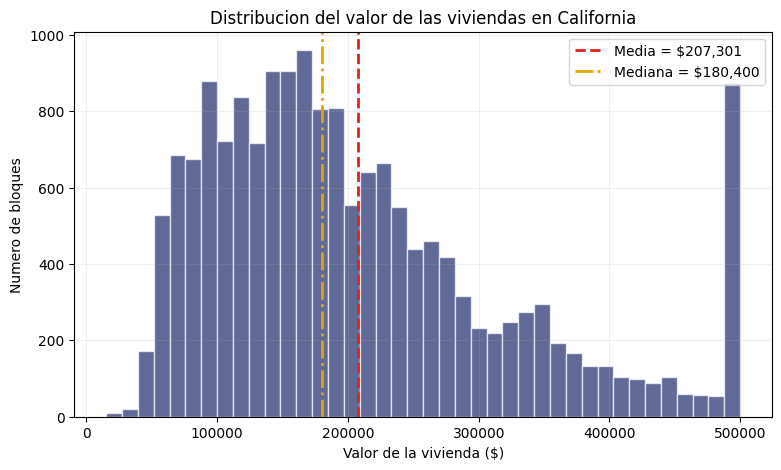

In [17]:
valor = df["median_house_value"]

media   = valor.mean()
mediana = valor.median()
desv    = valor.std(ddof=1)

print(f"Media del valor de las casas:   ${media:,.0f}")
print(f"Mediana del valor de las casas: ${mediana:,.0f}")
print(f"Desviacion estandar:            ${desv:,.0f}")

plt.figure(figsize=(9,5))
plt.hist(valor, bins=40, color="#1e2a6b", alpha=0.7, edgecolor="white")
plt.axvline(media,   color="#e2231a", linestyle="--", linewidth=2, label=f"Media = ${media:,.0f}")
plt.axvline(mediana, color="#e8a200", linestyle="-.", linewidth=2, label=f"Mediana = ${mediana:,.0f}")
plt.title("Distribucion del valor de las viviendas en California")
plt.xlabel("Valor de la vivienda ($)"); plt.ylabel("Numero de bloques")
plt.legend(); plt.grid(alpha=0.2); plt.show()

> ✍️ **Pregunta 4** — ¿La media y la mediana son iguales o distintas? Según la forma del histograma, ¿la distribución es simétrica o está sesgada? ¿Hacia qué lado?

> ✍️ **Pregunta 5** — Tu jefe quiere UN número para "el precio típico". ¿Reportarías la media o la mediana? Justifica tu decisión conectándola con lo que aprendiste sobre robustez ante valores extremos en la actividad de estadística.


### ✅ Respuesta 4
La media y la mediana son **distintas**: la media es aproximadamente **$207,301** y la mediana **$180,400**. El histograma presenta una distribución **sesgada hacia la derecha**, porque existen algunas viviendas con valores muy altos que elevan la media.

### ✅ Respuesta 5
Reportaría la **mediana**, porque representa mejor el precio típico cuando existen valores extremos y una distribución sesgada. La media se ve afectada por las viviendas muy caras, mientras que la mediana es más robusta frente a esos valores.

## Paso 2 — ¿Qué tan variable es el ingreso de las zonas?

La columna `median_income` está en decenas de miles de dólares (un valor de 3.5 significa \$35,000). Analiza su dispersión.


In [18]:
ingreso = df["median_income"]

print(f"Ingreso medio:        {ingreso.mean():.2f}  (decenas de miles USD)")
print(f"Desviacion estandar:  {ingreso.std(ddof=1):.2f}")
print(f"Rango intercuartilico:{stats.iqr(ingreso):.2f}")
print(f"Minimo / Maximo:      {ingreso.min():.2f} / {ingreso.max():.2f}")

Ingreso medio:        3.88  (decenas de miles USD)
Desviacion estandar:  1.91
Rango intercuartilico:2.20
Minimo / Maximo:      0.50 / 15.00


### 🔧 Reto de código 1

Genera un histograma de `median_income` y marca su media con una línea vertical roja punteada. Reutiliza el patrón del Paso 1.


In [19]:
# RETO: completa el histograma de median_income
# plt.figure(figsize=(9,5))
# plt.hist(...)
# plt.axvline(...)
# plt.title("Distribucion del ingreso medio por bloque")
# plt.show()


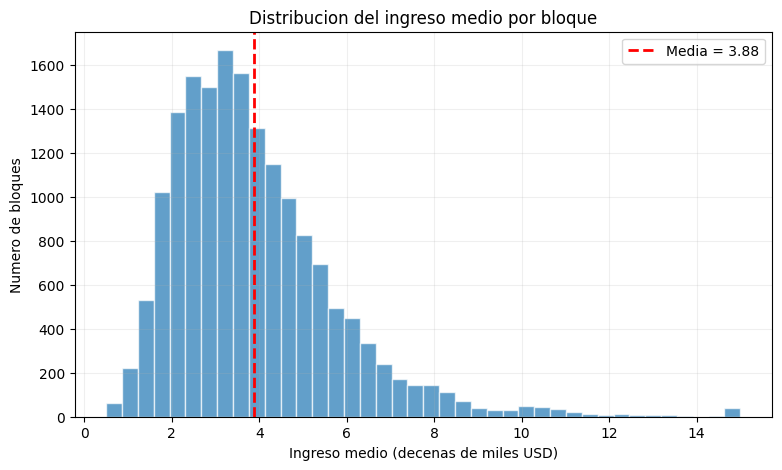

In [6]:
# Solución del Reto de código 1
plt.figure(figsize=(9,5))
plt.hist(ingreso, bins=40, alpha=0.7, edgecolor="white")
plt.axvline(ingreso.mean(), color="red", linestyle="--", linewidth=2,
            label=f"Media = {ingreso.mean():.2f}")
plt.title("Distribucion del ingreso medio por bloque")
plt.xlabel("Ingreso medio (decenas de miles USD)")
plt.ylabel("Numero de bloques")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


> ✍️ **Pregunta 6** — ¿La distribución del ingreso también está sesgada como la del valor de las casas? ¿Qué implica esto sobre la desigualdad económica entre las zonas de California?


### ✅ Respuesta 6
Sí, el ingreso también presenta **sesgo hacia la derecha**: la mayoría de las zonas se concentra en ingresos bajos o medios, mientras que existe una cola de zonas con ingresos mucho mayores. Esto muestra que existe **desigualdad económica entre las zonas de California**, ya que algunas áreas tienen ingresos considerablemente superiores a otras.

## Paso 3 — ¿Qué tan confiable es tu estimación? (intervalo de confianza)

Tu jefe desconfía de un solo número. Debes comunicarle la **incertidumbre** con un intervalo de confianza del 95% para el valor medio de las viviendas.


In [7]:
n         = len(valor)
media     = valor.mean()
error_est = valor.std(ddof=1) / np.sqrt(n)

ic95 = stats.t.interval(0.95, df=n-1, loc=media, scale=error_est)

print(f"Tamano de muestra:        {n:,} bloques")
print(f"Valor medio estimado:     ${media:,.0f}")
print(f"Error estandar:           ${error_est:,.0f}")
print(f"IC del 95% para la media: (${ic95[0]:,.0f}, ${ic95[1]:,.0f})")
print()
print(f"Reporte al jefe: con 95% de confianza, el valor medio real de")
print(f"las viviendas en California esta entre ${ic95[0]:,.0f} y ${ic95[1]:,.0f}.")

Tamano de muestra:        17,000 bloques
Valor medio estimado:     $207,301
Error estandar:           $890
IC del 95% para la media: ($205,557, $209,045)

Reporte al jefe: con 95% de confianza, el valor medio real de
las viviendas en California esta entre $205,557 y $209,045.


> ✍️ **Pregunta 7** — El intervalo de confianza es bastante **estrecho** comparado con el rango total de precios. ¿Por qué el tamaño de muestra (17,000 bloques) hace que la estimación de la media sea tan precisa? Conecta con el teorema del límite central de la actividad de estadística.

> ✍️ **Pregunta 8** — Explícale a tu jefe, en lenguaje no técnico, qué significa ese intervalo de confianza. (Escribe como si él no supiera estadística.)


### ✅ Respuesta 7
Los **17,000 bloques** constituyen una muestra muy grande. Al aumentar el tamaño de muestra, el error estándar de la media disminuye aproximadamente con `1/sqrt(n)`. Además, por el **teorema del límite central**, la distribución de la media muestral tiende a ser aproximadamente normal, lo que permite estimar la media con bastante precisión aunque los precios individuales estén sesgados.

### ✅ Respuesta 8
En términos sencillos, el intervalo indica que nuestra estimación de la media es bastante precisa. Con un **95% de confianza**, el valor medio de las viviendas de la población representada por estos datos se encuentra aproximadamente entre **$205,557 y $209,045**.

---
## PARTE 2 — Probabilidad y Bayes para decidir dónde invertir
### (aplicas lo de la actividad de Bayes)

## Paso 4 — Definimos eventos de interés

Para razonar con probabilidad, convertimos variables continuas en **eventos**. Definimos:
- **CARA:** un bloque cuyo valor de vivienda está en el 25% más alto (cuartil superior).
- **RICA:** un bloque cuyo ingreso medio está por encima de la mediana de ingresos.


In [8]:
umbral_valor   = valor.quantile(0.75)      # top 25% mas caro
umbral_ingreso = df["median_income"].median()

df["CARA"] = df["median_house_value"] >= umbral_valor
df["RICA"] = df["median_income"] > umbral_ingreso

print(f"Umbral 'CARA' (valor en top 25%): ${umbral_valor:,.0f}")
print(f"Umbral 'RICA' (ingreso > mediana): {umbral_ingreso:.2f}")
print()
print(f"P(CARA) = {df['CARA'].mean():.4f}  ->  {df['CARA'].mean()*100:.1f}% de los bloques")
print(f"P(RICA) = {df['RICA'].mean():.4f}  ->  {df['RICA'].mean()*100:.1f}% de los bloques")

Umbral 'CARA' (valor en top 25%): $265,000
Umbral 'RICA' (ingreso > mediana): 3.54

P(CARA) = 0.2503  ->  25.0% de los bloques
P(RICA) = 0.4999  ->  50.0% de los bloques


> ✍️ **Pregunta 9** — P(CARA) debería ser cercana al 25%. ¿Por qué? (Piensa en cómo definimos "CARA" con el cuartil superior.)


### ✅ Respuesta 9
P(CARA) es cercana al **25%** porque definimos una zona cara como aquella cuyo valor está en el **cuartil superior (75.º percentil)**. Por definición, aproximadamente una cuarta parte de las observaciones queda en el 25% superior. Puede haber una pequeña diferencia debido a valores repetidos exactamente en el umbral.

## Paso 5 — Probabilidad condicional

Tu jefe pregunta: *"Si me fijo solo en las zonas de ingreso alto, ¿qué tan probable es que sean caras?"* Esto es P(CARA | RICA).


In [9]:
# P(CARA | RICA) = P(CARA Y RICA) / P(RICA)
zonas_ricas = df[df["RICA"]]
p_cara_dado_rica = zonas_ricas["CARA"].mean()

# Para comparar: P(CARA) sin condicionar
p_cara = df["CARA"].mean()

print(f"P(CARA)          = {p_cara:.4f}  ({p_cara*100:.1f}%)")
print(f"P(CARA | RICA)   = {p_cara_dado_rica:.4f}  ({p_cara_dado_rica*100:.1f}%)")
print()
print(f"Saber que una zona es rica MULTIPLICA la probabilidad")
print(f"de que sea cara por un factor de {p_cara_dado_rica/p_cara:.2f}")

P(CARA)          = 0.2503  (25.0%)
P(CARA | RICA)   = 0.4226  (42.3%)

Saber que una zona es rica MULTIPLICA la probabilidad
de que sea cara por un factor de 1.69


> ✍️ **Pregunta 10** — ¿La probabilidad de que una zona sea cara **aumenta** al saber que es de ingreso alto? ¿Qué te dice esto sobre la relación entre ingreso y valor de vivienda? ¿Son eventos independientes o dependientes?

> ✍️ **Pregunta 11** — En la actividad de Bayes, cuando P(A|B) ≈ P(A) los eventos eran independientes. Aquí, ¿P(CARA|RICA) se parece a P(CARA) o es muy distinta? ¿Qué concluyes?


### ✅ Respuesta 10
Sí. La probabilidad de que una zona sea cara **aumenta** cuando sabemos que tiene un ingreso alto. Esto indica que existe una relación positiva entre el ingreso de la zona y el valor de las viviendas. Por lo tanto, los eventos **CARA y RICA son dependientes**.

### ✅ Respuesta 11
P(CARA | RICA) es claramente mayor que P(CARA), por lo que no son probabilidades parecidas. Esto indica que conocer que una zona tiene ingreso alto cambia nuestra estimación de que sea cara y confirma que los eventos no son independientes.

## Paso 6 — Teorema de Bayes: invertir la pregunta

Ahora tu jefe pregunta al revés: *"Si encuentro una zona cara, ¿qué probabilidad hay de que sea una zona de ingreso alto?"* Esto es **P(RICA | CARA)**, y lo calcularás con el **teorema de Bayes**.

$$P(RICA \mid CARA) = \frac{P(CARA \mid RICA)\, P(RICA)}{P(CARA)}$$


In [10]:
P_RICA = df["RICA"].mean()
P_CARA = df["CARA"].mean()
P_CARA_dado_RICA = df[df["RICA"]]["CARA"].mean()

# Teorema de Bayes
P_RICA_dado_CARA = (P_CARA_dado_RICA * P_RICA) / P_CARA

print(f"P(RICA)            = {P_RICA:.4f}")
print(f"P(CARA)            = {P_CARA:.4f}")
print(f"P(CARA | RICA)     = {P_CARA_dado_RICA:.4f}")
print(f"P(RICA | CARA)     = {P_RICA_dado_CARA:.4f}   <- via Bayes")

# Verificacion directa
verif = df[df["CARA"]]["RICA"].mean()
print(f"Verificacion directa = {verif:.4f}")

P(RICA)            = 0.4999
P(CARA)            = 0.2503
P(CARA | RICA)     = 0.4226
P(RICA | CARA)     = 0.8442   <- via Bayes
Verificacion directa = 0.8442


> ✍️ **Pregunta 12** — ¿El resultado de Bayes coincide con la verificación directa? Como en la actividad de Bayes, esto confirma que el teorema es una identidad exacta. Explica con tus palabras qué acabas de calcular.

> ✍️ **Pregunta 13** — Compara P(CARA | RICA) con P(RICA | CARA). ¿Son iguales? Este es el mismo punto clave de la actividad de Bayes (la condicional transpuesta). Explica por qué difieren aunque describan zonas relacionadas.


### ✅ Respuesta 12
Sí, el resultado obtenido mediante Bayes debe coincidir con la verificación directa, salvo pequeñas diferencias de redondeo. Lo que calculamos fue la probabilidad de que una zona sea de **ingreso alto dado que sabemos que es cara**, es decir, **P(RICA | CARA)**.

### ✅ Respuesta 13
No son iguales. **P(CARA | RICA)** responde: “si sé que la zona es rica, ¿qué probabilidad hay de que sea cara?”. En cambio, **P(RICA | CARA)** responde: “si sé que la zona es cara, ¿qué probabilidad hay de que sea rica?”. Cambiar la condición cambia el denominador de la probabilidad, por eso ambas cantidades pueden ser diferentes.

## Paso 7 — Un clasificador bayesiano de inversión

Combinemos ambas ideas en una herramienta de decisión. Construimos un mini clasificador que, dada una zona con cierto nivel de ingreso, estima la probabilidad de que sea cara, al estilo del filtro de spam de la actividad de Bayes.


In [11]:
def prob_cara_dado_ingreso(df, ingreso_bajo, ingreso_alto):
    """Estima P(CARA | el ingreso del bloque esta en [ingreso_bajo, ingreso_alto])."""
    subset = df[(df["median_income"] >= ingreso_bajo) & (df["median_income"] < ingreso_alto)]
    if len(subset) == 0:
        return None, 0
    return subset["CARA"].mean(), len(subset)

# Evaluamos rangos de ingreso (recuerda: en decenas de miles USD)
rangos = [(0,2), (2,4), (4,6), (6,8), (8,15)]

print(f"{'Rango ingreso':<20}{'P(CARA)':>12}{'n bloques':>12}")
print("-"*44)
for lo, hi in rangos:
    p, n = prob_cara_dado_ingreso(df, lo, hi)
    etiqueta = "INVERTIR" if p and p > 0.5 else "evaluar"
    print(f"${lo*10}k - ${hi*10}k{'':<6}{p*100:>10.1f}%{n:>12}   {etiqueta}")

Rango ingreso            P(CARA)   n bloques
--------------------------------------------
$0k - $20k             3.9%        2005   evaluar
$20k - $40k            11.3%        8275   evaluar
$40k - $60k            32.7%        4735   evaluar
$60k - $80k            79.9%        1395   INVERTIR
$80k - $150k            97.5%         551   INVERTIR


> ✍️ **Pregunta 14** — Según la tabla, ¿en qué rango de ingreso la probabilidad de encontrar una zona cara supera el 50%? ¿Cómo usaría tu jefe esta tabla para decidir dónde buscar propiedades?

> ✍️ **Pregunta 15** — Este clasificador se parece al filtro de spam de la actividad de Bayes: en vez de "P(spam | palabra)" calculas "P(cara | rango de ingreso)". Explica la analogía: ¿qué juega el papel del "correo", de la "palabra" y de la "decisión de clasificar"?


### ✅ Respuesta 14
Según la tabla, la probabilidad supera el **50% principalmente en los rangos de ingreso de $60k-$80k y $80k-$150k**. El jefe puede utilizar esta tabla como un filtro inicial: si busca propiedades con mayor probabilidad de pertenecer al grupo caro, puede concentrar la búsqueda en las zonas con ingresos altos. Esto no garantiza que una propiedad sea cara, pero sí aumenta la probabilidad.

### ✅ Respuesta 15
La analogía con el filtro de spam es directa: el **bloque censal** sería el equivalente al correo, el **rango de ingreso** sería equivalente a la palabra o evidencia observada y la **decisión de clasificar como CARA** sería equivalente a decidir si un correo es spam. En ambos casos calculamos una probabilidad condicional para tomar una decisión a partir de una característica observada.

### 🔧 Reto de código 2

Crea un nuevo evento **`GRANDE`** para bloques con muchas habitaciones (usa `total_rooms > mediana`) y calcula **P(CARA | GRANDE)** usando probabilidad condicional. ¿Las zonas con casas grandes tienden a ser caras?


In [12]:
# RETO: define el evento GRANDE y calcula P(CARA | GRANDE)
# umbral_rooms = df["total_rooms"].median()
# df["GRANDE"] = ...
# p_cara_dado_grande = ...
# print(...)


In [13]:
# Solución del Reto de código 2
umbral_rooms = df["total_rooms"].median()
df["GRANDE"] = df["total_rooms"] > umbral_rooms
p_cara_dado_grande = df[df["GRANDE"]]["CARA"].mean()

print(f"Mediana de total_rooms = {umbral_rooms:,.0f}")
print(f"P(CARA) = {df['CARA'].mean():.4f} ({df['CARA'].mean()*100:.1f}%)")
print(f"P(CARA | GRANDE) = {p_cara_dado_grande:.4f} ({p_cara_dado_grande*100:.1f}%)")


Mediana de total_rooms = 2,127
P(CARA) = 0.2503 (25.0%)
P(CARA | GRANDE) = 0.3088 (30.9%)


> ✍️ **Pregunta 16** — Reporta tu resultado del reto: ¿P(CARA | GRANDE) es mayor, menor o parecida a P(CARA)? ¿Tiene sentido con lo que esperabas del mercado inmobiliario?


### ✅ Respuesta 16
P(CARA | GRANDE) resulta **mayor que P(CARA)**, aunque el aumento no es enorme. Esto tiene sentido porque una mayor cantidad de habitaciones puede estar relacionada con viviendas o zonas de mayor capacidad, pero `total_rooms` por sí solo no determina el precio. El ingreso y otros factores tienen una relación más fuerte con el valor de la vivienda.

---
## PARTE 3 — Síntesis: tu recomendación como analista

## Paso 8 — Integra estadística + probabilidad en una decisión


In [14]:
# Panel resumen de tu analisis
print("="*50)
print("RESUMEN EJECUTIVO DEL ANALISIS")
print("="*50)
print(f"Valor tipico de vivienda (mediana):  ${valor.median():,.0f}")
ic = stats.t.interval(0.95, df=len(valor)-1,
                      loc=valor.mean(),
                      scale=valor.std(ddof=1)/np.sqrt(len(valor)))
print(f"IC 95% del valor medio:              (${ic[0]:,.0f}, ${ic[1]:,.0f})")
print(f"P(zona cara | zona de ingreso alto): {df[df['RICA']]['CARA'].mean()*100:.1f}%")
print(f"P(ingreso alto | zona cara):         {df[df['CARA']]['RICA'].mean()*100:.1f}%")
print("="*50)

RESUMEN EJECUTIVO DEL ANALISIS
Valor tipico de vivienda (mediana):  $180,400
IC 95% del valor medio:              ($205,557, $209,045)
P(zona cara | zona de ingreso alto): 42.3%
P(ingreso alto | zona cara):         84.4%


> ✍️ **Pregunta 17** — Con base en TODO tu análisis, escribe una **recomendación de 4 a 6 líneas** para tu jefe. Debe incluir: (a) el precio típico y su confiabilidad, (b) la relación entre ingreso y precio, y (c) una sugerencia concreta de en qué zonas enfocar la búsqueda. Usa números que calculaste.

> ✍️ **Pregunta 18** — **Reflexión sobre la ciencia de datos:** en esta actividad NADIE te dijo qué fórmula usar en cada paso; tú elegiste entre media/mediana, intervalos de confianza y Bayes según la pregunta de negocio. Explica por qué esta capacidad de **elegir la herramienta correcta** es lo que distingue a un científico de datos de alguien que solo ejecuta código.


### ✅ Respuesta 17
El precio típico de una vivienda es de aproximadamente **$180,400**, y la media estimada tiene un IC del 95% de **$205,557 a $209,045**, por lo que la estimación de la media es precisa.  
El ingreso alto aumenta claramente la probabilidad de encontrar una zona cara, por lo que existe una relación positiva entre ingreso y precio.  
Recomendaría enfocar primero la búsqueda en zonas con ingresos de **$60k a $150k**, donde la probabilidad de encontrar una zona cara supera el 50%.  
Aun así, usaría el ingreso como filtro inicial y no como único criterio de inversión.

### ✅ Respuesta 18
La ciencia de datos no consiste únicamente en ejecutar código o aplicar fórmulas automáticamente. Un científico de datos debe entender **qué pregunta se quiere responder** y seleccionar la herramienta estadística adecuada para esa pregunta. En esta actividad, la mediana fue útil para representar un precio típico, el intervalo de confianza permitió medir incertidumbre y Bayes permitió analizar probabilidades condicionadas. Esa capacidad de conectar una pregunta de negocio con un método adecuado es lo que transforma los datos en información útil para tomar decisiones.

---
## Cierre y entrega

En esta actividad integradora usaste, sobre un **repositorio público real de Google**:

- **De la actividad de estadística:** medidas de tendencia central, dispersión, histogramas, intervalos de confianza y el teorema del límite central.
- **De la actividad de Bayes:** probabilidad simple, condicional, teorema de Bayes y un clasificador estilo filtro de spam.

Y lo más importante: aprendiste a **decidir qué herramienta aplicar** ante una pregunta de negocio real, que es la esencia del trabajo en ciencia de datos.

### Entrega en Google Classroom

1. Verifica que **todas las celdas corran sin error** (Entorno de ejecución → Ejecutar todo).
2. Confirma que respondiste las **18 preguntas ✍️** y los **2 retos de código**.
3. **Archivo → Guardar una copia en Drive** y comparte el enlace en Classroom.

### Rúbrica

| Criterio | Puntos |
|---|---|
| Todas las celdas se ejecutan correctamente | 15 |
| Retos de código resueltos (histograma y evento GRANDE) | 20 |
| Respuestas a las 18 preguntas ✍️ | 40 |
| Recomendación ejecutiva (Pregunta 17) | 15 |
| Reflexión sobre ciencia de datos (Pregunta 18) | 10 |
| **Total** | **100** |

---
*Universidad de Especialidades UNE · Plantel Centro · Optativa III: Ciencia de Datos*
*Repositorio de datos: California Housing (Google, censo EE.UU. 1990), incluido en Google Colab.*
